In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('Weight-Height.csv')
df.head()


,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

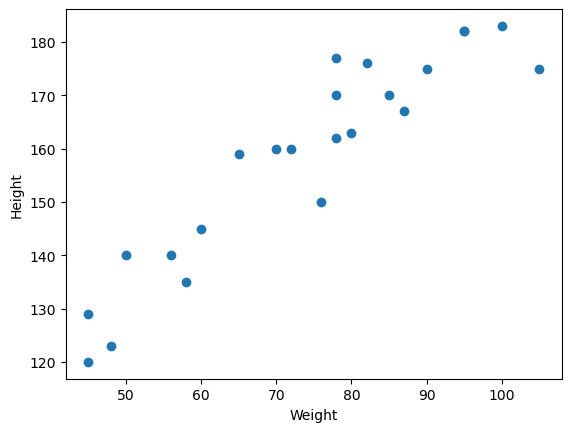

In [5]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


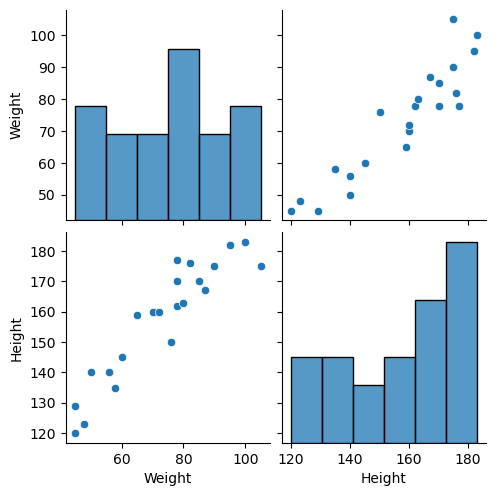

In [1]:
import seaborn as sns
sns.pairplot(df)

NameError: name 'df' is not defined

In [ ]:
#independent in 2D and dependent var in 1D
X=df[["Weight"]]#independent
y=df["Height"]#dependent

(23,)

In [15]:
#splitting the data for training and testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
#standardization(Grad Descent applies only to independent var)
#in order to avoid data leakage, use only fit() on testing data.
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
#Applying Linear Regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)
y_pred=regression.predict(X_test_scaled)
print(regression.coef_)
print(regression.intercept_)


[17.2982057]
156.47058823529412


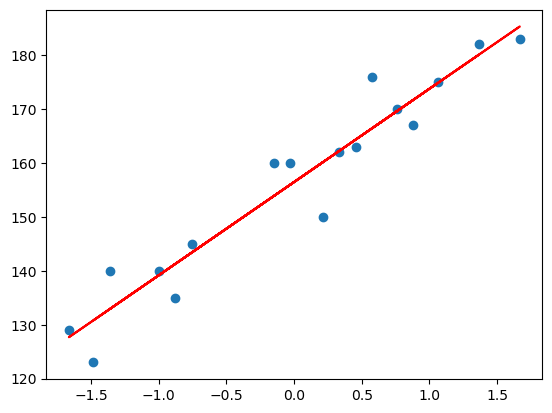

In [22]:
#plot training data
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,regression.predict(X_train_scaled),color='r')

In [23]:
#prediction on test data
y_pred


array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [ ]:
#performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(rmse)

114.84069295228699
9.665125886795005
0.7360826717981276
10.716374991212605


In [26]:
#OLS technique
import statsmodels.api as sm
model=sm.OLS(y_train,sm.add_constant(X_train_scaled)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     174.5
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.15e-09
Time:                        11:35:18   Log-Likelihood:                -51.726
No. Observations:                  17   AIC:                             107.5
Df Residuals:                      15   BIC:                             109.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        156.4706      1.310    119.477      0.0

In [29]:
#prediction on new data
regression.predict(scaler.transform([[72]]))


c:\Users\karra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])